In [1]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.svm import SVC
import pandas_ta as ta
import os
import nolds
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier
import joblib  # 用于保存和加载缩放器


In [2]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, mean_squared_error
import numpy as np


class XGBoostModel:
    def __init__(self, params=None, num_boost_round=100):
        """ 
        初始化XGBoost模型类。
         :param params: dict, XGBoost的参数字典。例如：{'objective': 'reg:squarederror', 'max_depth': 6, 'eta': 0.3}
        :param num_boost_round: int, boosting的轮数
        """
        self.params = params if params else {'objective': 'reg:squarederror', 'max_depth': 6, 'eta': 0.3}
        self.num_boost_round = num_boost_round
        self.model = None

    def train(self, X_train, y_train, X_val=None, y_val=None, early_stopping_rounds=10):
        """
        训练XGBoost模型。
        
        :param X_train: np.array or pd.DataFrame, 训练特征
        :param y_train: np.array or pd.Series, 训练标签
        :param X_val: np.array or pd.DataFrame, 验证特征（可选）
        :param y_val: np.array or pd.Series, 验证标签（可选）
        :param early_stopping_rounds: int, 早停的轮数（仅在提供验证集时有效）
        """
        dtrain = xgb.DMatrix(X_train, label=y_train)
        if X_val is not None and y_val is not None:
            dval = xgb.DMatrix(X_val, label=y_val)
            evals = [(dtrain, 'train'), (dval, 'eval')]
            self.model = xgb.train(
                self.params, dtrain, num_boost_round=self.num_boost_round, evals=evals,
                early_stopping_rounds=early_stopping_rounds, verbose_eval=True
            )
        else:
            self.model = xgb.train(self.params, dtrain, num_boost_round=self.num_boost_round)

    def predict(self, X):
        """
        使用训练好的模型进行预测。
        
        :param X: np.array or pd.DataFrame, 输入特征
        :return: np.array, 预测结果
        """
        dtest = xgb.DMatrix(X)
        return self.model.predict(dtest)

    def evaluate(self, X, y, metric='accuracy'):
        """
        评估模型性能。
        
        :param X: np.array or pd.DataFrame, 输入特征
        :param y: np.array or pd.Series, 真实标签
        :param metric: str, 性能指标（'accuracy' 或 'rmse'）
        :return: float, 性能分数
        """
        y_pred = self.predict(X)
        if metric == 'accuracy':
            y_pred_binary = np.round(y_pred)  # 适用于分类问题
            return accuracy_score(y, y_pred_binary)
        elif metric == 'rmse':
            return np.sqrt(mean_squared_error(y, y_pred))
        else:
            raise ValueError("Unsupported metric. Use 'accuracy' or 'rmse'.")

    def save_model(self, path):
        """
        保存模型到文件。
        
        :param path: str, 模型保存路径
        """
        self.model.save_model(path)

    def load_model(self, path):
        """
        从文件加载模型。
        
        :param path: str, 模型文件路径
        """
        self.model = xgb.Booster()
        self.model.load_model(path)

In [3]:

from sklearn.preprocessing import MinMaxScaler
import joblib
import os

def load_and_prepare_data(file_path, scaler_path=None, save_scaler=True, normalization='global', window_size=1000):
    """
    加载数据并处理特征，同时应用预定义缩放规则。
    :param file_path: str, 数据文件路径
    :param scaler_path: str, 保存或加载缩放器的路径。如果为 None，则不保存。
    :param save_scaler: bool, 是否保存新的缩放器（仅在未提供 scaler_path 时生效）。
    :param normalization: str, 归一化方法（'global', 'sliding'）。
    :param window_size: int, 滑动窗口大小，仅在 'sliding' 方法中使用。
    :return: np.array, 特征矩阵 X 和标签 y
    """
    # 加载数据
    df = pd.read_pickle(file_path)  # 假设数据为 DataFrame 格式
    X, y = load_and_prepare_data_real(df)  # 提取特征和标签

    # 应用归一化方法
    if normalization == 'sliding':
        print(f'Use Sliding win:{window_size}')
        X_scaled = sliding_window_normalize(X, window_size=window_size)
        y = y[window_size - 1:]  # 调整标签大小，保持与滑动窗口对齐
    elif normalization == 'global':
        if scaler_path and os.path.exists(scaler_path):
            # 加载已有缩放器
            scaler = joblib.load(scaler_path)
            print(f"缩放器已加载: {scaler_path}")
        else:
            # 创建新的全局缩放器
            scaler = MinMaxScaler()
            scaler.fit(X)
            if save_scaler and scaler_path:
                joblib.dump(scaler, scaler_path)
                print(f"缩放器已保存: {scaler_path}")
        X_scaled = scaler.transform(X)
    else:
        raise ValueError("Unsupported normalization method. Use 'sliding' or 'global'.")

    return X_scaled, y


def sliding_window_normalize(X, window_size=1000):
    """
    使用滑动窗口对时间序列数据进行归一化，并只提取每个窗口的最后一个时间步特征。
    :param X: list or np.array, 输入特征矩阵
    :param window_size: int, 滑动窗口大小
    :return: np.array, 归一化后的特征矩阵，仅保留窗口内最后一个时间步
    """
    X = np.array(X)  # 确保输入为 NumPy 数组
    normalized_features = []

    for i in range(window_size - 1, len(X)):
        if i % 100 == 0: print(f'{i}|{len(X)}')
        # 取窗口数据
        window = X[i - window_size + 1:i + 1]

        # 计算最小值和最大值
        min_val = np.min(window, axis=0)
        max_val = np.max(window, axis=0)

        # 归一化窗口数据
        normalized_window = (window - min_val) / (max_val - min_val + 1e-8)

        # 提取最后一个时间步
        normalized_features.append(normalized_window[-1])

    return np.array(normalized_features)


def load_and_prepare_data_real(df):
    # 对数收益率
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))

    # 移动均线
    df['MA5'] = df['close'].rolling(window=5).mean()
    df['MA20'] = df['close'].rolling(window=20).mean()
    df['MA50'] = df['close'].rolling(window=50).mean()
    df['MA100'] = df['close'].rolling(window=100).mean()

    # 布林带
    df['std_20'] = df['close'].rolling(window=20).std()
    df['BB_upper'] = df['MA20'] + 2 * df['std_20']
    df['BB_lower'] = df['MA20'] - 2 * df['std_20']
    df['BB_width'] = df['BB_upper'] - df['BB_lower']

    # 动量和趋势特征
    df['momentum_5'] = df['close'] - df['close'].shift(5)
    df['momentum_10'] = df['close'] - df['close'].shift(10)
    df['momentum_20'] = df['close'] - df['close'].shift(20)

    # 价格变化率 (Rate of Change)
    df['roc_5'] = df['close'].pct_change(5)
    df['roc_10'] = df['close'].pct_change(10)
    df['roc_20'] = df['close'].pct_change(20)
    df['roc_30'] = df['close'].pct_change(30)
    df['roc_60'] = df['close'].pct_change(60)

    # True Strength Index (TSI)
    tsi = df.ta.tsi(close=df['close'], fast=13, slow=25)

    if isinstance(tsi, pd.DataFrame):
        df['TSI'] = tsi.iloc[:, 0]  # 选择第一列作为结果

    else:
        df['TSI'] = tsi  # 单列结果直接赋值

    # MACD 指标
    macd = df.ta.macd(close=df['close'])
    df['MACD'] = macd['MACD_12_26_9']
    df['MACD_signal'] = macd['MACDs_12_26_9']
    df['MACD_hist'] = macd['MACDh_12_26_9']
    # 随机震荡指标 (Stochastic Oscillator)
    stoch = df.ta.stoch(high=df['high'], low=df['low'], close=df['close'], k=14, d=3, smooth_k=3)
    df['stochastic_k'] = stoch['STOCHk_14_3_3']
    df['stochastic_d'] = stoch['STOCHd_14_3_3']
    # Ichimoku 云指标
    # 计算 Ichimoku 指标
    ichimoku = df.ta.ichimoku(high=df['high'], low=df['low'], close=df['close'], tenkan=9, kijun=26, senkou=52)
    # 合并两个部分
    ichimoku_combined = pd.concat(ichimoku, axis=0)
    # 提取所需的列
    df['Tenkan_sen'] = ichimoku_combined['ITS_9']    # 转换线 (Tenkan-sen)
    df['Kijun_sen'] = ichimoku_combined['IKS_26']    # 基准线 (Kijun-sen)
    df['Senkou_Span_A'] = ichimoku_combined['ISA_9']  # 先行 A 线 (Senkou Span A)
    df['Senkou_Span_B'] = ichimoku_combined['ISB_26']  # 先行 B 线 (Senkou Span B)

    # Parabolic SAR# Parabolic SAR
    psar = ta.psar(high=df['high'], low=df['low'], close=df['close'])
    # 将相关的列添加到主 DataFrame
    df['PSAR_long'] = psar['PSARl_0.02_0.2']  # Long方向的PSAR
    df['PSAR_short'] = psar['PSARs_0.02_0.2']  # Short方向的PSAR
    df['PSAR_af'] = psar['PSARaf_0.02_0.2']  # 加速因子
    df['PSAR_reversal'] = psar['PSARr_0.02_0.2']  # 反转点
    
    # 平均方向性指数 (ADX)
    adx = df.ta.adx(high=df['high'], low=df['low'], close=df['close'], length=14)
    df['ADX'] = adx['ADX_14']
    df['PDI'] = adx['DMP_14']
    df['NDI'] = adx['DMN_14']
    df['DX'] = abs(df['PDI'] - df['NDI']) / (df['PDI'] + df['NDI']) * 100
    # 成交量特征
    df['Volume_MA5'] = df['volume'].rolling(window=5).mean()
    df['Volume_MA20'] = df['volume'].rolling(window=20).mean()
    df['price_to_volume'] = df['close'] / (df['volume'] + 1e-9)
    df['volume_acceleration'] = df['volume'].diff().diff()

    # 量价指标
    # On-Balance Volume (OBV)
    df['OBV'] = df.ta.obv(close=df['close'], volume=df['volume'])
    df['OBV_change'] = df['OBV'].diff()
    # 使用优化函数
    df['rolling_skew'] = df.ta.skew(close=df['log_return'], length=20)
    df['rolling_kurtosis'] = df.ta.kurtosis(close=df['log_return'], length=20)

    # 价格模式识别 (示例：Hammer Pattern)
    body = abs(df['close'] - df['open'])
    range_ = df['high'] - df['low']
    lower_shadow = np.minimum(df['close'], df['open']) - df['low']
    df['is_hammer'] = ((lower_shadow > 2 * body) & (body / range_ < 0.3)).astype(int)

    # 滞后特征 (过去5天的MA20)
    for lag in range(1, 6):
        df[f'MA20_lag_{lag}'] = df['MA20'].shift(lag)

    # 提取所有特征
    features = [
        'open', 'high', 'low', 'close', 'volume',
        'MA5', 'MA20', 'MA50', 'MA100',
        'BB_upper', 'BB_lower', 'BB_width',
        'log_return', 'momentum_5', 'momentum_10', 'momentum_20',
        'roc_5', 'roc_10', 'roc_20', 'roc_30', 'roc_60',
        'TSI',
        'MACD', 'MACD_signal', 'MACD_hist',
        'stochastic_k', 'stochastic_d',
        'Tenkan_sen', 'Kijun_sen', 'Senkou_Span_A', 'Senkou_Span_B',
        'PSAR_af', 'PSAR_reversal',
        'ADX', 'PDI', 'NDI', 'DX',
        'Volume_MA5', 'Volume_MA20', 'price_to_volume', 'volume_acceleration',
        'OBV', 'OBV_change',
        'rolling_skew', 'rolling_kurtosis',
        'is_hammer'
    ]
    for lag in range(1, 6):
        features.append(f'MA20_lag_{lag}')

    df['position_signal'] = df['position_signal'].map({'long': 1, 'short': 0})
    df.dropna(subset=features + ['position_signal'], inplace=True)
    X = df[features].values
    y = df['position_signal'].values
    return X,y

In [4]:
data_file_path = "LSTMdata.pkl"  # Path to your saved DataFrame
model_save_path = "xgboost_model.json"  # Path where model will be saved
scaler_save_path = "scaler.pkl"
os.makedirs("plots", exist_ok=True)

# Load and prepare the data
# X, y = load_and_prepare_data(data_file_path,scaler_save_path,normalization='sliding', window_size=100)
X, y = load_and_prepare_data(data_file_path,scaler_save_path,normalization='global', window_size=100)

缩放器已加载: scaler.pkl


In [5]:
def time_series_split(data, labels, train_ratio=0.7, val_ratio=0.2):
    """
    时间序列分割，将数据按时间顺序划分为训练、验证和测试集。
    
    :param data: np.array, 特征矩阵
    :param labels: np.array, 标签
    :param train_ratio: float, 训练集比例
    :param val_ratio: float, 验证集比例
    :return: X_train, X_val, X_test, y_train, y_val, y_test
    """
    n = len(data)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)

    X_train = data[:train_end]
    y_train = labels[:train_end]
    X_val = data[train_end:val_end]
    y_val = labels[train_end:val_end]
    X_test = data[val_end:]
    y_test = labels[val_end:]

    return X_train, X_val, X_test, y_train, y_val, y_test

In [6]:
# 数据集划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
# X_train, X_val, X_test, y_train, y_val, y_test = time_series_split(X, y, train_ratio=0.8, val_ratio=0.15)

In [7]:
xgb_model = XGBoostModel()
xgb_model.train(X_train, y_train, X_val, y_val)

# 保存模型
model_save_path = "xgboost_model.json"
xgb_model.save_model(model_save_path)

[0]	train-rmse:0.49744	eval-rmse:0.49758
[1]	train-rmse:0.49594	eval-rmse:0.49615
[2]	train-rmse:0.49481	eval-rmse:0.49505
[3]	train-rmse:0.49407	eval-rmse:0.49441
[4]	train-rmse:0.49272	eval-rmse:0.49316
[5]	train-rmse:0.49175	eval-rmse:0.49239
[6]	train-rmse:0.49007	eval-rmse:0.49089
[7]	train-rmse:0.48932	eval-rmse:0.49033
[8]	train-rmse:0.48882	eval-rmse:0.48994
[9]	train-rmse:0.48817	eval-rmse:0.48939
[10]	train-rmse:0.48711	eval-rmse:0.48843
[11]	train-rmse:0.48674	eval-rmse:0.48818
[12]	train-rmse:0.48602	eval-rmse:0.48763
[13]	train-rmse:0.48573	eval-rmse:0.48749
[14]	train-rmse:0.48517	eval-rmse:0.48705
[15]	train-rmse:0.48463	eval-rmse:0.48666
[16]	train-rmse:0.48395	eval-rmse:0.48607
[17]	train-rmse:0.48287	eval-rmse:0.48520
[18]	train-rmse:0.48213	eval-rmse:0.48460
[19]	train-rmse:0.48125	eval-rmse:0.48375
[20]	train-rmse:0.48004	eval-rmse:0.48267
[21]	train-rmse:0.47969	eval-rmse:0.48252
[22]	train-rmse:0.47910	eval-rmse:0.48203
[23]	train-rmse:0.47858	eval-rmse:0.48165
[2

[1 0 1 ... 1 0 1]
训练集准确率: 0.71


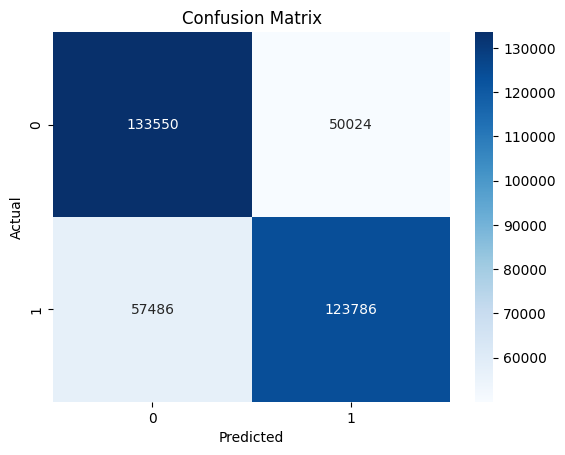

In [8]:
#训练集性能比较
xgb_model.load_model(model_save_path)
y_pred_binary_train = xgb_model.predict(X_train)
y_pred_train = (y_pred_binary_train > 0.5).astype(int)  
print(y_pred_train)

# 计算准确率
accuracy = accuracy_score(y_train, y_pred_train)
print(f"训练集准确率: {accuracy:.2f}")
# 绘制混淆矩阵
cm = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

测试集准确率: 0.66


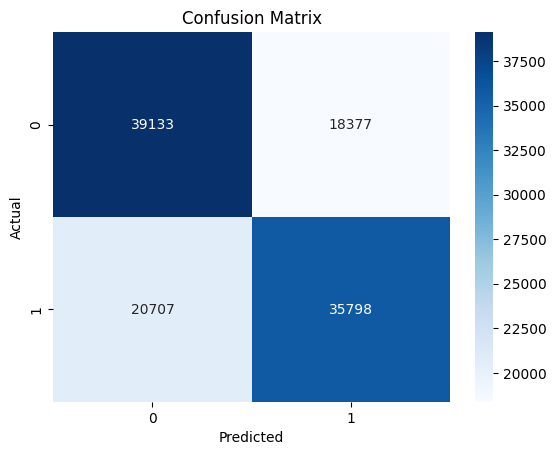

In [9]:
#测试集准确率比较

xgb_model.load_model(model_save_path)
y_pred_binary = xgb_model.predict(X_test)
y_pred = (y_pred_binary > 0.5).astype(int)  # 将概率转化为类别标签，例如 [1, 0, 1]

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)

print(f"测试集准确率: {accuracy:.2f}")


# 绘制混淆矩阵

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
def custom_threshold(y_pred, low_threshold=0.3, high_threshold=0.7):
    """
    根据自定义的阈值范围对预测结果进行分类。
    
    :param y_pred: np.array, XGBoost 的预测概率
    :param low_threshold: float, 下限阈值（低于此值为 0）
    :param high_threshold: float, 上限阈值（高于此值为 1）
    :return: np.array, 应用阈值后的分类结果
    """
    y_custom = np.where(y_pred < low_threshold, 0,  # 低于 low_threshold 分为 0
                        np.where(y_pred > high_threshold, 1, 0.5))  # 高于 high_threshold 分为 1，其余为 0.5
    return y_custom


def filter_ambiguous(y_test, y_pred, threshold=0.5):
    """
    去除 y_test 和 y_pred 中所有预测值为指定阈值的位置。
    
    :param y_test: np.array, 真实标签
    :param y_pred: np.array, 预测值
    :param threshold: float, 要过滤的阈值（默认 0.5）
    :return: tuple, 过滤后的 y_test 和 y_pred
    """
    mask = y_pred != threshold  # 创建掩码，过滤掉 y_pred 中等于阈值的元素
    y_test_filtered = y_test[mask]
    y_pred_filtered = y_pred[mask]
    return y_test_filtered, y_pred_filtered

去除后测试集准确率: 0.91


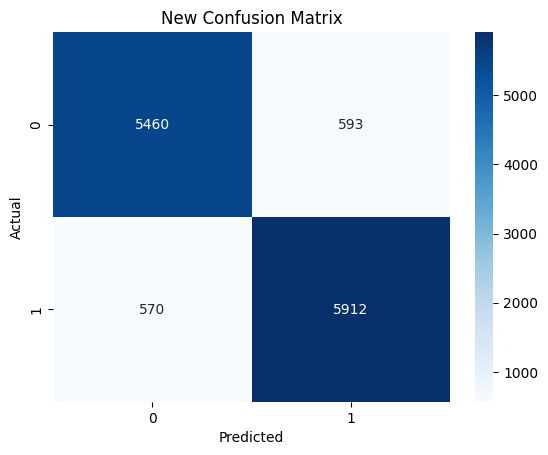

In [11]:
# 设置自定义阈值
low_threshold = 0.3
high_threshold = 0.7

# 应用自定义分类规则
y_pred2 = custom_threshold(y_pred_binary, low_threshold=low_threshold, high_threshold=high_threshold)
y_test_filtered, y_pred_filtered = filter_ambiguous(y_test, y_pred2, threshold=0.5)

accuracy = accuracy_score(y_test_filtered, y_pred_filtered)
print(f"去除后测试集准确率: {accuracy:.2f}")

# 绘制混淆矩阵
cm = confusion_matrix(y_test_filtered, y_pred_filtered)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("New Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
def prepare_test_data(file_path, window_size=100):
    """
    从测试数据中提取滑动窗口，并生成特征矩阵和对应标签。
    每个滑动窗口都调用 `load_and_prepare_data_real` 进行特征处理。
    
    :param file_path: 测试数据文件路径
    :param window_size: 滑动窗口大小
    :return: 测试特征矩阵 X_test 和标签 y_test
    """
    # 加载数据
    df = pd.read_pickle(file_path)

    # 滑动窗口处理
    X_test_windows = []
    y_test_windows = []
    for start_idx in  range(500 - window_size + 1):
    ##range(len(df) - window_size + 1):
        # 取当前滑动窗口数据
        window_df = df.iloc[start_idx:start_idx + window_size].copy()

        # 调用 `load_and_prepare_data_real` 对窗口数据进行特征处理
        X_window, y_window = load_and_prepare_data_real(window_df)

        # 添加窗口最后一个点的特征和标签
        X_test_windows.append(X_window[-1])  # 只取最后一行特征
        y_test_windows.append(y_window[-1])  # 只取最后一行标签

    # 转换为 NumPy 数组
    X_test = np.array(X_test_windows)
    y_test = np.array(y_test_windows)
    # print(f"生成测试集滑动窗口矩阵，形状为: {X_test.shape}, 标签形状为: {y_test.shape}")

    return X_test, y_test

In [13]:
# 文件路径
test_data_file_path = "LSTMTestData.pkl"

# 滑动窗口大小
window_size = 100
# 生成测试特征矩阵和标签
# X_test2, y_test2 = prepare_test_data(test_data_file_path, window_size=window_size)
X_test2, y_test2 = load_and_prepare_data(test_data_file_path,scaler_save_path)


缩放器已加载: scaler.pkl


测试集准确率: 0.52


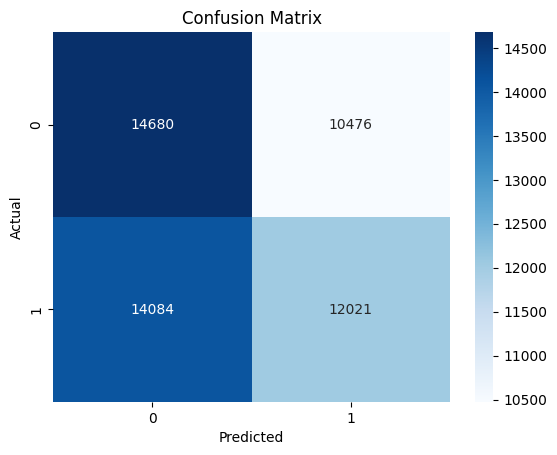

In [14]:

# 使用已保存的模型进行预测
xgb_model.load_model(model_save_path)
y_pred_binary = xgb_model.predict(X_test2)
y_pred2 = (y_pred_binary > 0.5).astype(int)  # 将概率转化为类别标签，例如 [1, 0, 1]

# 计算准确率
accuracy = accuracy_score(y_test2, y_pred2)
print(f"测试集准确率: {accuracy:.2f}")


# 绘制混淆矩阵
cm = confusion_matrix(y_test2, y_pred2)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

去除后测试集准确率: 0.54


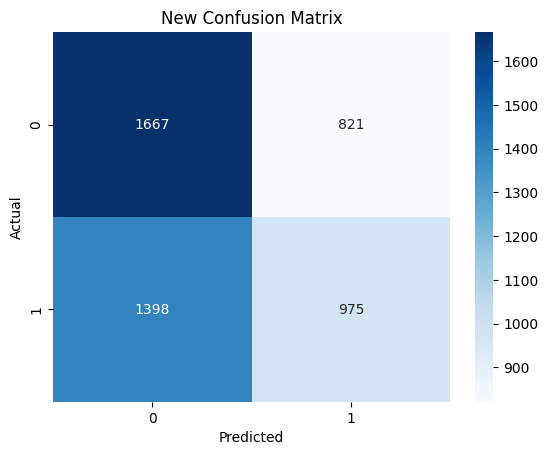

In [15]:

# 设置自定义阈值
low_threshold = 0.3
high_threshold = 0.7

# 应用自定义分类规则
y_pred3 = custom_threshold(y_pred_binary, low_threshold=low_threshold, high_threshold=high_threshold)

y_test_filtered, y_pred_filtered = filter_ambiguous(y_test2, y_pred3, threshold=0.5)

accuracy = accuracy_score(y_test_filtered, y_pred_filtered)
print(f"去除后测试集准确率: {accuracy:.2f}")

# 绘制混淆矩阵
cm = confusion_matrix(y_test_filtered, y_pred_filtered)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("New Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

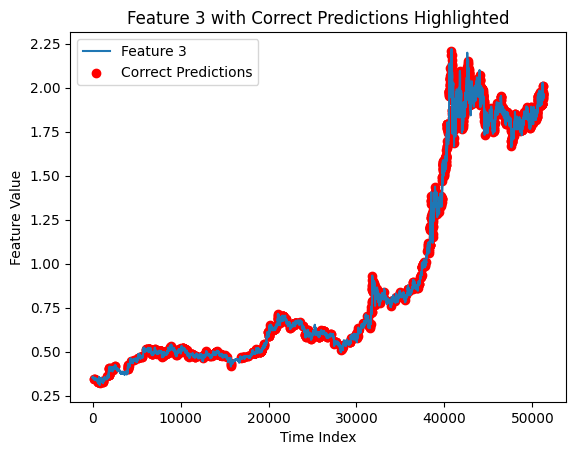

In [16]:
tt = range(len(X_test2))  # 时间序列
plt.plot(tt, X_test2[:, 3], label='Feature 3')  # 绘制特征 3 的曲线
correct_indices = np.where(y_test2 == y_pred3)[0]
plt.scatter(correct_indices, X_test2[correct_indices, 3], color='red', label='Correct Predictions')
plt.legend()
plt.title('Feature 3 with Correct Predictions Highlighted')
plt.xlabel('Time Index')
plt.ylabel('Feature Value')
plt.show()

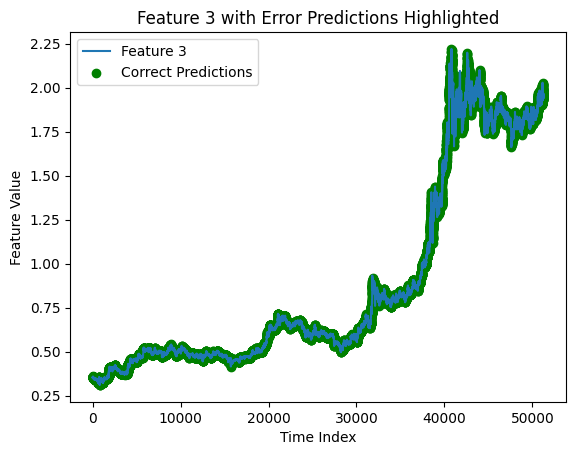

In [17]:
tt = range(len(X_test2))  # 时间序列
plt.plot(tt, X_test2[:, 3], label='Feature 3')  # 绘制特征 3 的曲线
correct_indices = np.where(y_test2 != y_pred3)[0]
plt.scatter(correct_indices, X_test2[correct_indices, 3], color='green', label='Correct Predictions')
plt.legend()
plt.title('Feature 3 with Error Predictions Highlighted')
plt.xlabel('Time Index')
plt.ylabel('Feature Value')
plt.show()

In [18]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import accuracy_score, mean_squared_error


class IncrementalXGBoost:
    def __init__(self, params=None, num_boost_round=50, window_size=None):
        self.params = params if params else {'objective': 'binary:logistic', 'max_depth': 6, 'eta': 0.1}
        self.num_boost_round = num_boost_round
        self.window_size = window_size
        self.model = None
        self.history_X = []
        self.history_y = []

    def update_window(self, X_new, y_new):
        if self.window_size:
            self.history_X.extend(X_new)
            self.history_y.extend(y_new)
            if len(self.history_X) > self.window_size:
                self.history_X = self.history_X[-self.window_size:]
                self.history_y = self.history_y[-self.window_size:]
        else:
            self.history_X.extend(X_new)
            self.history_y.extend(y_new)

    def reset_window(self, X, y):
        self.history_X = list(X)
        self.history_y = list(y)

    def train(self, X_new, y_new, X_val=None, y_val=None, incremental=False):
        if not incremental:
            self.reset_window(X_new, y_new)
        else:
            self.update_window(X_new, y_new)

        X_train = np.array(self.history_X)
        y_train = np.array(self.history_y)
        dtrain = xgb.DMatrix(X_train, label=y_train)

        evals = []
        if X_val is not None and y_val is not None:
            dval = xgb.DMatrix(X_val, label=y_val)
            evals = [(dtrain, 'train'), (dval, 'eval')]

        if self.model:
            self.model = xgb.train(
                self.params, dtrain, num_boost_round=self.num_boost_round, evals=evals,
                xgb_model=self.model, verbose_eval=False
            )
        else:
            self.model = xgb.train(
                self.params, dtrain, num_boost_round=self.num_boost_round, evals=evals,
                verbose_eval=False
            )

    def predict(self, X):
        if not self.model:
            raise ValueError("模型尚未训练，无法进行预测。")
        dtest = xgb.DMatrix(X)
        return self.model.predict(dtest)

    def sliding_train_predict(self, X, y,train_size=20, window_size=100, step_size=1):
        predictions = []
        for i in range(0, len(X) - window_size, step_size):
            train_window_X = X[i:i + train_size - 1]
            train_window_y = y[i:i + train_size - 1]
            test_point = X[i + window_size - 1].reshape(1, -1)
            self.train(train_window_X, train_window_y, incremental=False)
            pred = self.predict(test_point)[0]
            predictions.append(pred)            
            print(f"{i}/{len(X) - window_size} : Pred-{pred} | True-{y[i + window_size - 1].reshape(1, -1)}")
        return predictions

    def evaluate(self, X, y, metric='accuracy'):
        y_pred = self.predict(X)
        if metric == 'accuracy':
            y_pred_binary = np.round(y_pred)
            return accuracy_score(y, y_pred_binary)
        elif metric == 'rmse':
            return np.sqrt(mean_squared_error(y, y_pred))
        elif metric == 'New_accuracy':            
            y_pred_binary=custom_threshold(y_pred, low_threshold=0.3, high_threshold=0.7)          
            y_test_filtered, y_pred_filtered = filter_ambiguous(y, y_pred_binary, threshold=0.5)
            return accuracy_score(y_test_filtered, y_pred_filtered),y_test_filtered, y_pred_filtered
        else:
            raise ValueError("Unsupported metric. Use 'accuracy' or 'rmse'.")

    def save_model(self, path):
        self.model.save_model(path)

    def load_model(self, path):
        self.model = xgb.Booster()
        self.model.load_model(path)
